# Model 6 — Feature Association Rule Mining (Apriori)

## Research Question
What combinations of car features tend to appear together — and do certain combinations reliably predict very expensive, very cheap, or heavily damaged cars?

## Introduction
This notebook uses the **Apriori algorithm** (`mlxtend`) to discover association rules between binary car features.

**Rules for this notebook:**
- Uses **unscaled data** (`proceed_dataset_without_scaling.csv`)
- You **must use `apriori` from `mlxtend`** — no other algorithm is acceptable
- You **must engineer the binary columns** described in the Feature Engineering section before running Apriori
- You **may adjust `min_support` and `min_confidence` thresholds** to explore different rule sets
- You **may choose different features**, add features — but you **cannot change the general technique category** (must remain Apriori / association rule mining)

## Data Import

Run this cell as-is. It loads all required libraries and the unscaled dataset.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install mlxtend
from mlxtend.frequent_patterns import apriori, association_rules

df = pd.read_csv('https://raw.githubusercontent.com/MamoMGD1/ISE302-DataMining-GroupProject/main/data/proceed_dataset_without_scaling.csv')
print(f"Dataset shape: {df.shape}")
df.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.9 MB/s  0:00:00
Dataset shape: (2589, 87)


,Fiyat,Yıl,Kilometre,İlan Tarihi,Ortalama Kasko,Ortalama Trafik Sigortası,Üretim Yılı (İlk/Son),Silindir Sayısı,Koltuk Sayısı,Bagaj Hacmi,...,Hızlanma (0-100),Maksimum Hız,Uzunluk,Genişlik,Yükseklik,Ağırlık,Boş Ağırlığı,Aks Aralığı,Jant Boyutu,log_Fiyat
0,2425000,2025,6001,0.507585,9.730597,9.436162,2024.524726,3,5,6.255935,...,10.1,198.0,8.388223,1806.0,1590.0,7.530480,1315.0,7.881182,17,14.701342
1,2900000,2025,16000,0.540567,9.801196,9.426602,2024.561718,4,5,6.312241,...,9.2,199.0,8.395252,1848.0,1625.0,7.591862,1450.0,7.888335,19,14.880222
2,1150000,2015,265000,0.437396,9.847922,9.310729,2015.500000,4,5,5.996452,...,12.4,180.0,8.384804,1800.0,1590.0,7.555382,1365.0,7.881182,19,13.955273
3,1240000,2014,196000,0.403619,9.796904,9.310729,2015.500000,4,5,5.996452,...,10.7,182.0,8.384804,1800.0,1590.0,7.603898,1461.0,7.881182,17,14.030623
4,690000,2011,305000,0.354720,9.696057,9.341037,2011.476979,4,5,6.115519,...,12.2,174.0,8.370084,1780.0,1615.0,7.565793,1407.0,7.875119,16,13.444448


## Feature Engineering

Run this cell as-is. It creates seven custom binary columns that will be used as special items in the transaction matrix:

| Column | Meaning |
|---|---|
| `cok_pahali` | Price ≥ 95th percentile |
| `cok_ucuz` | Price ≤ 5th percentile |
| `yuksek_km` | Mileage > 150,000 km |
| `dusuk_km` | Mileage < 30,000 km |
| `yeni_araba` | Year ≥ 2022 |
| `eski_araba` | Year ≤ 2015 |
| `agir_hasar` | Damage score ≥ 75th percentile |

In [13]:
# Create custom binary columns for association mining
df['cok_pahali'] = (df['Fiyat'] >= df['Fiyat'].quantile(0.95)).astype(int)
df['cok_ucuz']   = (df['Fiyat'] <= df['Fiyat'].quantile(0.05)).astype(int)
df['yuksek_km']  = (df['Kilometre'] > 150000).astype(int)
df['dusuk_km']   = (df['Kilometre'] < 30000).astype(int)
df['yeni_araba'] = (df['Yıl'] >= 2022).astype(int)
df['eski_araba'] = (df['Yıl'] <= 2015).astype(int)
df['agir_hasar'] = (df['paint_damage_score'] >= df['paint_damage_score'].quantile(0.75)).astype(int)

print("Engineered columns created:")
for col in ['cok_pahali', 'cok_ucuz', 'yuksek_km', 'dusuk_km', 'yeni_araba', 'eski_araba', 'agir_hasar']:
    print(f"  {col}: {df[col].sum()} cars ({df[col].mean()*100:.1f}%)")

Engineered columns created:
  cok_pahali: 130 cars (5.0%)
  cok_ucuz: 130 cars (5.0%)
  yuksek_km: 837 cars (32.3%)
  dusuk_km: 402 cars (15.5%)
  yeni_araba: 773 cars (29.9%)
  eski_araba: 823 cars (31.8%)
  agir_hasar: 828 cars (32.0%)


## Transaction Dataset Construction

Run this cell as-is. It combines the engineered binary columns with all existing one-hot encoded columns (body type, fuel type, drivetrain, seller type, brand flags) into a boolean transaction matrix suitable for Apriori.

In [14]:
# Combine engineered columns with existing binary one-hot columns
engineered_cols = ['cok_pahali', 'cok_ucuz', 'yuksek_km', 'dusuk_km',
                   'yeni_araba', 'eski_araba', 'agir_hasar']

# Find all existing binary one-hot columns
onehot_patterns = ['Kasa Tipi_', 'Yakıt Tipi_', 'Çekiş_', 'Kimden_', 'is_Nissan']
onehot_cols = [c for c in df.columns for p in onehot_patterns if c.startswith(p)]

transaction_cols = engineered_cols + onehot_cols
transaction_cols = [c for c in transaction_cols if c in df.columns]

transactions = df[transaction_cols].fillna(0).astype(bool)
print(f"Transaction matrix: {transactions.shape[0]} rows × {transactions.shape[1]} items")
print(f"Total item columns: {transactions.columns.tolist()}")

Transaction matrix: 2589 rows × 23 items
Total item columns: ['cok_pahali', 'cok_ucuz', 'yuksek_km', 'dusuk_km', 'yeni_araba', 'eski_araba', 'agir_hasar', 'is_Nissan', 'Kimden_Sahibinden', 'Kimden_Yetkili Bayiden', 'Yakıt Tipi_Dizel', 'Yakıt Tipi_Elektrik', 'Yakıt Tipi_Hibrit', 'Yakıt Tipi_LPG & Benzin', 'Kasa Tipi_Coupe', 'Kasa Tipi_Crossover', 'Kasa Tipi_Hard top', 'Kasa Tipi_Panelvan', 'Kasa Tipi_Pick-Up', 'Kasa Tipi_SUV', 'Çekiş_AWD (Elektronik)', 'Çekiş_Arkadan İtiş', 'Çekiş_Önden Çekiş']


## Frequent Itemset Mining

**TODO (Student Task):** Run the Apriori algorithm to find frequent itemsets.

- Lower `min_support` → more itemsets found, but may include noisy/spurious ones
- Higher `min_support` → fewer, more reliable itemsets
- Adjust `max_len` to control the maximum number of items per itemset

In [15]:
# TODO: Adjust min_support. Lower values find more rules but may be noisy.
# Recommended starting point: 0.05 (5% of transactions)
frequent_itemsets = apriori(
    transactions,
    min_support=0.05,      # TODO: try 0.03, 0.08, 0.10
    use_colnames=True,
    max_len=4              # TODO: max items per itemset
)
print(f"Found {len(frequent_itemsets)} frequent itemsets")
frequent_itemsets.sort_values('support', ascending=False).head(20)

Found 194 frequent itemsets


,support,itemsets
11,0.950560,frozenset({Kasa Tipi_SUV})
13,0.791039,frozenset({Çekiş_Önden Çekiş})
57,0.770954,"frozenset({Çekiş_Önden Çekiş, Kasa Tipi_SUV})"
7,0.517574,frozenset({is_Nissan})
9,0.491696,frozenset({Yakıt Tipi_Dizel})
47,0.471224,"frozenset({Kasa Tipi_SUV, is_Nissan})"
52,0.454616,"frozenset({Kasa Tipi_SUV, Yakıt Tipi_Dizel})"
48,0.443028,"frozenset({Çekiş_Önden Çekiş, is_Nissan})"
123,0.424874,"frozenset({Çekiş_Önden Çekiş, Kasa Tipi_SUV, i..."
8,0.368482,frozenset({Kimden_Sahibinden})


## Association Rules Generation

**TODO (Student Task):** Generate association rules from the frequent itemsets.

- Higher `min_threshold` for confidence → fewer but more reliable rules
- Sort by `lift` to find rules where the co-occurrence is much higher than chance

In [16]:
# TODO: Adjust min_threshold for confidence. Higher = fewer but more reliable rules.
rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.5      # TODO: try 0.6, 0.7
)
rules = rules.sort_values('lift', ascending=False)
print(f"Total rules generated: {len(rules)}")
rules.head(10)

Total rules generated: 511


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
379,"frozenset({Kasa Tipi_SUV, yeni_araba, Kimden_S...",frozenset({dusuk_km}),0.100425,0.155272,0.058710,0.584615,3.765098,1.0,0.043117,2.033604,0.816388,0.298039,0.508262,0.481362
381,"frozenset({yeni_araba, Kimden_Sahibinden})","frozenset({dusuk_km, Kasa Tipi_SUV})",0.101584,0.154114,0.058710,0.577947,3.750136,1.0,0.043055,2.004217,0.816262,0.298039,0.501052,0.479450
100,"frozenset({yeni_araba, Kimden_Sahibinden})",frozenset({dusuk_km}),0.101584,0.155272,0.059096,0.581749,3.746638,1.0,0.043323,2.019667,0.815985,0.298828,0.504869,0.481173
98,"frozenset({yeni_araba, is_Nissan})",frozenset({dusuk_km}),0.090769,0.155272,0.050599,0.557447,3.590124,1.0,0.036505,1.908760,0.793481,0.258893,0.476100,0.441659
386,"frozenset({dusuk_km, Kasa Tipi_SUV})","frozenset({Çekiş_Önden Çekiş, yeni_araba})",0.154114,0.233681,0.115102,0.746867,3.196098,1.0,0.079089,3.027340,0.812306,0.422096,0.669677,0.619715
106,frozenset({dusuk_km}),"frozenset({Çekiş_Önden Çekiş, yeni_araba})",0.155272,0.233681,0.115875,0.746269,3.193536,1.0,0.079591,3.020199,0.813123,0.424328,0.668896,0.621068
388,frozenset({dusuk_km}),"frozenset({Çekiş_Önden Çekiş, Kasa Tipi_SUV, y...",0.155272,0.232136,0.115102,0.741294,3.193359,1.0,0.079058,2.968090,0.813102,0.422695,0.663083,0.618567
101,"frozenset({dusuk_km, Kasa Tipi_SUV})",frozenset({yeni_araba}),0.154114,0.298571,0.145616,0.944862,3.164616,1.0,0.099602,12.721374,0.808626,0.474214,0.921392,0.716286
103,frozenset({dusuk_km}),"frozenset({Kasa Tipi_SUV, yeni_araba})",0.155272,0.296640,0.145616,0.937811,3.161449,1.0,0.099556,11.310035,0.809361,0.475410,0.911583,0.714348
10,frozenset({dusuk_km}),frozenset({yeni_araba}),0.155272,0.298571,0.146389,0.942786,3.157663,1.0,0.100029,12.259761,0.808912,0.476131,0.918432,0.716542


## Evaluation

### Top Rules Predicting Very Expensive Cars (`cok_pahali`)

Filters rules whose consequent is `cok_pahali` and ranks them by confidence.

> ⚠️ This cell uses placeholder data for illustration. Replace with your actual association rules after running Apriori.

In [17]:
# ⚠️ Replace rules with your actual association rules after running apriori.
pahali_rules = rules[rules['consequents'].apply(lambda x: 'cok_pahali' in x)]
pahali_rules_sorted = pahali_rules.sort_values('confidence', ascending=False).head(10)

print("=== Top 10 Rules Predicting VERY EXPENSIVE Cars ===\n")
display_cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
if len(pahali_rules_sorted) > 0:
    styled = pahali_rules_sorted[display_cols].reset_index(drop=True)
    styled['antecedents'] = styled['antecedents'].apply(lambda x: ', '.join(list(x)))
    styled['consequents'] = styled['consequents'].apply(lambda x: ', '.join(list(x)))
    print(styled.to_string(index=False))
    strong = pahali_rules_sorted[pahali_rules_sorted['lift'] > 2.0]
    if len(strong) > 0:
        print(f"\n⭐ {len(strong)} rule(s) with lift > 2.0 (STRONG associations):")
        for _, r in strong.iterrows():
            print(f"   {set(r['antecedents'])} → {set(r['consequents'])} | lift={r['lift']:.2f}")
else:
    print("No rules found. Try lowering min_support or min_threshold.")

=== Top 10 Rules Predicting VERY EXPENSIVE Cars ===

No rules found. Try lowering min_support or min_threshold.


### Top Rules Predicting Very Cheap Cars (`cok_ucuz`)

Filters rules whose consequent is `cok_ucuz` and ranks them by confidence.

> ⚠️ This cell uses placeholder data for illustration. Replace with your actual association rules.

In [18]:
# ⚠️ Replace rules with your actual association rules.
ucuz_rules = rules[rules['consequents'].apply(lambda x: 'cok_ucuz' in x)]
ucuz_rules_sorted = ucuz_rules.sort_values('confidence', ascending=False).head(10)

print("=== Top 10 Rules Predicting VERY CHEAP Cars ===\n")
if len(ucuz_rules_sorted) > 0:
    styled = ucuz_rules_sorted[display_cols].reset_index(drop=True).copy()
    styled['antecedents'] = styled['antecedents'].apply(lambda x: ', '.join(list(x)))
    styled['consequents'] = styled['consequents'].apply(lambda x: ', '.join(list(x)))
    print(styled.to_string(index=False))
else:
    print("No rules found. Try lowering min_support or min_threshold.")

=== Top 10 Rules Predicting VERY CHEAP Cars ===

No rules found. Try lowering min_support or min_threshold.


### Top Rules Predicting Heavily Damaged Cars (`agir_hasar`)

Filters rules whose consequent is `agir_hasar` and ranks them by confidence.

> ⚠️ This cell uses placeholder data for illustration. Replace with your actual association rules.

In [19]:
# ⚠️ Replace rules with your actual association rules.
hasar_rules = rules[rules['consequents'].apply(lambda x: 'agir_hasar' in x)]
hasar_rules_sorted = hasar_rules.sort_values('confidence', ascending=False).head(10)

print("=== Top 10 Rules Predicting HEAVILY DAMAGED Cars ===\n")
if len(hasar_rules_sorted) > 0:
    styled = hasar_rules_sorted[display_cols].reset_index(drop=True).copy()
    styled['antecedents'] = styled['antecedents'].apply(lambda x: ', '.join(list(x)))
    styled['consequents'] = styled['consequents'].apply(lambda x: ', '.join(list(x)))
    print(styled.to_string(index=False))
else:
    print("No rules found. Try lowering min_support or min_threshold.")

=== Top 10 Rules Predicting HEAVILY DAMAGED Cars ===

                                antecedents consequents  support  confidence     lift
           is_Nissan, eski_araba, yuksek_km  agir_hasar 0.086906    0.565327 1.767670
    Yakıt Tipi_Dizel, eski_araba, yuksek_km  agir_hasar 0.085361    0.555276 1.736245
        Kasa Tipi_SUV, is_Nissan, yuksek_km  agir_hasar 0.111240    0.554913 1.735109
   Çekiş_Önden Çekiş, eski_araba, yuksek_km  agir_hasar 0.091155    0.553991 1.732224
    Çekiş_Önden Çekiş, is_Nissan, yuksek_km  agir_hasar 0.100811    0.552966 1.729021
       Kasa Tipi_SUV, eski_araba, yuksek_km  agir_hasar 0.110081    0.550193 1.720350
                      eski_araba, yuksek_km  agir_hasar 0.118579    0.540493 1.690020
Kasa Tipi_SUV, eski_araba, Yakıt Tipi_Dizel  agir_hasar 0.087679    0.539192 1.685953
                       is_Nissan, yuksek_km  agir_hasar 0.120896    0.536878 1.678717
     Yakıt Tipi_Dizel, is_Nissan, yuksek_km  agir_hasar 0.102742    0.535211 1.673505


### Top 10 Rules by Lift (Strongest Natural Associations)

Lift > 1 means the items co-occur more than expected by chance. Lift > 2 is considered a strong association.

> ⚠️ This cell uses placeholder data for illustration. Replace with your actual association rules.

In [20]:
# ⚠️ Replace rules with your actual association rules.
top_lift = rules.sort_values('lift', ascending=False).head(10)
print("=== Top 10 Rules by Lift (Strongest Natural Associations) ===\n")
styled = top_lift[display_cols].reset_index(drop=True).copy()
styled['antecedents'] = styled['antecedents'].apply(lambda x: ', '.join(list(x)))
styled['consequents'] = styled['consequents'].apply(lambda x: ', '.join(list(x)))
print(styled.to_string(index=False))

strong_all = rules[rules['lift'] > 2.0]
print(f"\n⭐ Total rules with lift > 2.0: {len(strong_all)}")

=== Top 10 Rules by Lift (Strongest Natural Associations) ===

                                 antecedents                                  consequents  support  confidence     lift
Kasa Tipi_SUV, yeni_araba, Kimden_Sahibinden                                     dusuk_km 0.058710    0.584615 3.765098
               yeni_araba, Kimden_Sahibinden                      dusuk_km, Kasa Tipi_SUV 0.058710    0.577947 3.750136
               yeni_araba, Kimden_Sahibinden                                     dusuk_km 0.059096    0.581749 3.746638
                       yeni_araba, is_Nissan                                     dusuk_km 0.050599    0.557447 3.590124
                     dusuk_km, Kasa Tipi_SUV                Çekiş_Önden Çekiş, yeni_araba 0.115102    0.746867 3.196098
                                    dusuk_km                Çekiş_Önden Çekiş, yeni_araba 0.115875    0.746269 3.193536
                                    dusuk_km Çekiş_Önden Çekiş, Kasa Tipi_SUV, yeni_araba 0.11510

### Support vs Confidence Scatter Plot

Each point is one association rule. Point size encodes lift. Color indicates the type of consequent:
- 🔴 Red = `cok_pahali` (very expensive)
- 🔵 Blue = `cok_ucuz` (very cheap)
- 🟣 Purple = `agir_hasar` (heavy damage)
- ⚫ Grey = other consequents

> ⚠️ This cell uses placeholder data for illustration. Replace with your actual association rules.

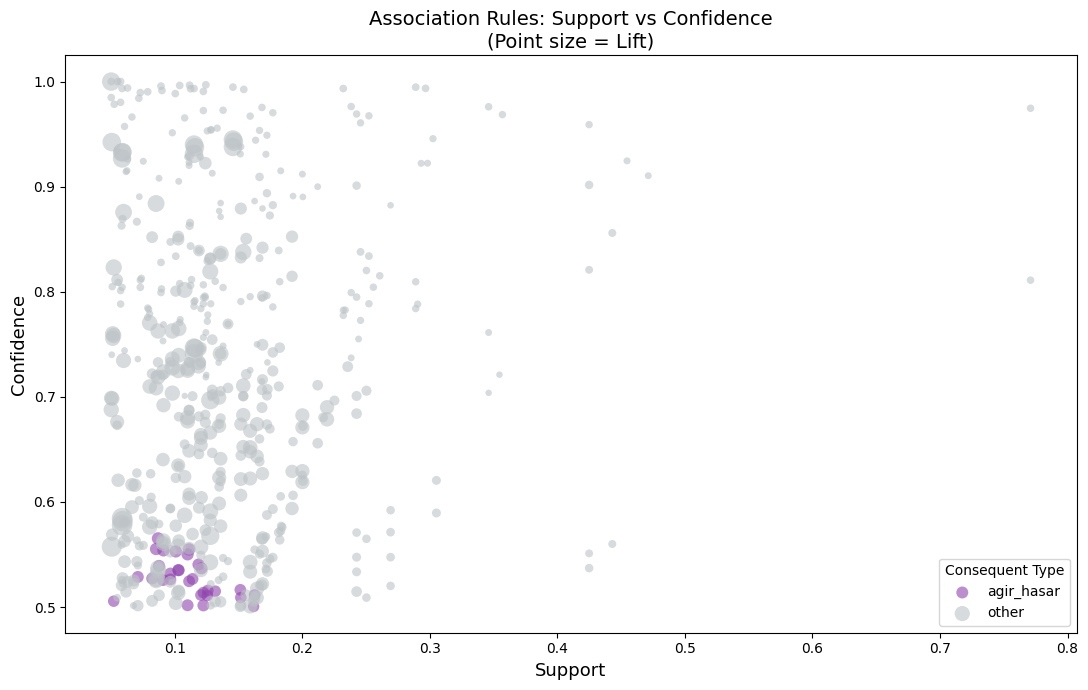

In [21]:
# ⚠️ Replace rules with your actual association rules.
target_consequents = ['cok_pahali', 'cok_ucuz', 'agir_hasar']
color_map = {'cok_pahali': '#e74c3c', 'cok_ucuz': '#3498db', 'agir_hasar': '#8e44ad', 'other': '#bdc3c7'}

def get_color(row):
    for t in target_consequents:
        if t in row['consequents']:
            return color_map[t]
    return color_map['other']

plot_rules = rules.copy()
plot_rules['color'] = plot_rules.apply(get_color, axis=1)
plot_rules['lift_scaled'] = (plot_rules['lift'] - plot_rules['lift'].min()) / (plot_rules['lift'].max() - plot_rules['lift'].min() + 1e-9) * 200 + 20

fig, ax = plt.subplots(figsize=(11, 7))
for label, color in color_map.items():
    mask = plot_rules['color'] == color
    if mask.sum() > 0:
        ax.scatter(plot_rules.loc[mask, 'support'],
                   plot_rules.loc[mask, 'confidence'],
                   s=plot_rules.loc[mask, 'lift_scaled'],
                   c=color, alpha=0.6, label=label, edgecolors='none')

ax.set_xlabel('Support', fontsize=13)
ax.set_ylabel('Confidence', fontsize=13)
ax.set_title('Association Rules: Support vs Confidence\n(Point size = Lift)', fontsize=14)
ax.legend(title='Consequent Type')
plt.tight_layout()
plt.show()

### Top 10 Rules by Lift — Bar Chart

Horizontal bar chart of the 10 rules with the highest lift. Rules with lift > 2.0 are highlighted in red.

> ⚠️ This cell uses placeholder data for illustration. Replace with your actual association rules.

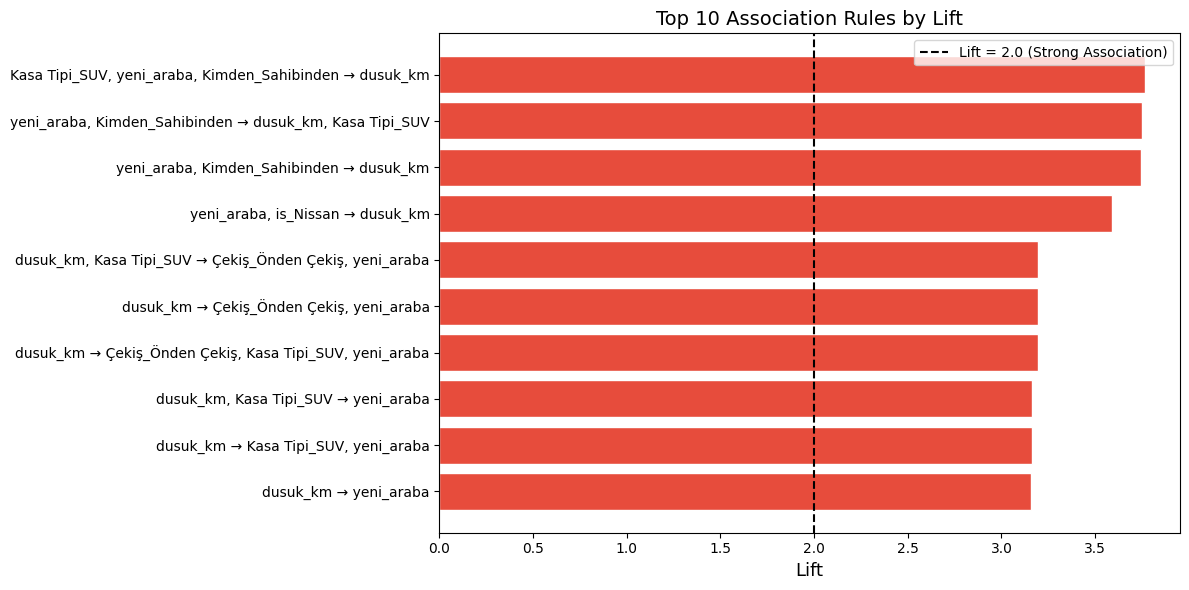

In [22]:
# ⚠️ Replace rules with your actual association rules.
top10_lift = rules.nlargest(10, 'lift').reset_index(drop=True)
top10_lift['rule_label'] = top10_lift.apply(
    lambda r: f"{', '.join(list(r['antecedents']))} → {', '.join(list(r['consequents']))}", axis=1)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#e74c3c' if r['lift'] > 2 else '#3498db' for _, r in top10_lift.iterrows()]
ax.barh(top10_lift['rule_label'], top10_lift['lift'], color=colors, edgecolor='white')
ax.axvline(2.0, color='black', linestyle='--', linewidth=1.5, label='Lift = 2.0 (Strong Association)')
ax.set_xlabel('Lift', fontsize=13)
ax.set_title('Top 10 Association Rules by Lift', fontsize=14)
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## ⚠️ If Your Model Underperforms

If your model produces poor or surprising results (e.g., very low accuracy, unexpected associations, or trivial rules), **do not discard your results**.

- Keep all outputs as-is
- In your presentation, document exactly what you observe
- Write a short hypothesis: Why might the model have failed? (e.g., 'The dataset may not contain enough transactions with rare feature combinations to produce reliable high-confidence rules')